setup

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

rs = 42
np.random.seed(rs)
df = pd.read_excel("ready_for_modeling_1.xlsx")
for x in ['religionAffiliation', 
          'specialDemographic', 
          'mergingInstitutionPopulation', 
          'mergingInstitutionType', 
          'mergingInstitutionLocationType', 
          'mergingInstitutionReligiousAffiliation',]:
    df[x] = df[x].fillna('None')
df['endowmentMedian'] = df['endowmentMedian'].fillna(-1)
df.drop(columns=['mergingInstitutionPopulation'], inplace=True)
df.head()

,name,yearEstablished,state,stateAbbreviation,locationType,locationTypeKind,typeOwned,typeProfit,level,hasUndergraduate,...,stateFourYearAppropriationsPerFTEMedian,stateTwoYearNetTuitionRevenuePerFTEMedian,stateFourYearNetTuitionRevenuePerFTEMedian,statePopulation18to24yoMedian,statePopulation25yoAndOverMedian,statePopulation18to24yoHighSchoolGradMedian,statePopulation25yoAndOverHighSchoolGradMedian,statePopulation18to24yoSomeCollegeOrHigherMedian,statePopulation25yoAndOverSomeCollegeOrHigherMedian,statePerCapitaPersonalIncomeMedian
0,Alderson Broaddus University,1871,West Virginia,WV,Rural,Distant,Private,Nonprofit,4-year,True,...,5634.822870,3552.459646,8324.661159,79926.5,612398.0,60470.5,512687.5,79926.5,612398.0,51075
1,Alliance University (Formerly Nyack College),1882,New York,NY,City,Large,Private,Nonprofit,4-year,True,...,14514.215742,4968.842112,7115.076497,1126667.0,8594351.5,497059.0,3517833.0,1126667.0,8594351.5,78501
2,Ancilla College,1937,Indiana,IN,Rural,Distant,Private,Nonprofit,2-year,True,...,6263.361828,3082.258414,12604.847801,337715.5,2531049.0,228011.0,1484195.5,337715.5,2531049.0,59797
3,Becker College,1784,Massachusetts,MA,City,Midsize,Private,Nonprofit,4-year,True,...,12392.121586,3823.431201,8164.798013,433897.0,3292373.5,194673.5,1135221.5,433897.0,3292373.5,85585
4,Bloomfield College,1868,New Jersey,NJ,Suburb,Large,Private,Nonprofit,4-year,True,...,10431.614347,3230.813658,11047.054665,469274.0,4014028.0,225395.0,1672783.5,469274.0,4014028.0,78329


combining reason of closures into a single feature

In [19]:
df.loc[df['name'].isin(['Independence University', 'Alliance University (Formerly Nyack College)']), 'reasonFinancial'] = True

reason_cols = ['reasonFinancial', 'reasonEnrollment', 'reasonPandemic', 'reasonMutualBenefit']
def create_reason_closure(row):
    reasons = [str(i) for i, reason in enumerate(reason_cols) if row[reason]]
    return ''.join(sorted(reasons)) if reasons else 'None'

df['reasonClosure'] = df.apply(create_reason_closure, axis=1)
df.head()

,name,yearEstablished,state,stateAbbreviation,locationType,locationTypeKind,typeOwned,typeProfit,level,hasUndergraduate,...,stateTwoYearNetTuitionRevenuePerFTEMedian,stateFourYearNetTuitionRevenuePerFTEMedian,statePopulation18to24yoMedian,statePopulation25yoAndOverMedian,statePopulation18to24yoHighSchoolGradMedian,statePopulation25yoAndOverHighSchoolGradMedian,statePopulation18to24yoSomeCollegeOrHigherMedian,statePopulation25yoAndOverSomeCollegeOrHigherMedian,statePerCapitaPersonalIncomeMedian,reasonClosure
0,Alderson Broaddus University,1871,West Virginia,WV,Rural,Distant,Private,Nonprofit,4-year,True,...,3552.459646,8324.661159,79926.5,612398.0,60470.5,512687.5,79926.5,612398.0,51075,0
1,Alliance University (Formerly Nyack College),1882,New York,NY,City,Large,Private,Nonprofit,4-year,True,...,4968.842112,7115.076497,1126667.0,8594351.5,497059.0,3517833.0,1126667.0,8594351.5,78501,0
2,Ancilla College,1937,Indiana,IN,Rural,Distant,Private,Nonprofit,2-year,True,...,3082.258414,12604.847801,337715.5,2531049.0,228011.0,1484195.5,337715.5,2531049.0,59797,3
3,Becker College,1784,Massachusetts,MA,City,Midsize,Private,Nonprofit,4-year,True,...,3823.431201,8164.798013,433897.0,3292373.5,194673.5,1135221.5,433897.0,3292373.5,85585,12
4,Bloomfield College,1868,New Jersey,NJ,Suburb,Large,Private,Nonprofit,4-year,True,...,3230.813658,11047.054665,469274.0,4014028.0,225395.0,1672783.5,469274.0,4014028.0,78329,0


splitting

In [20]:
labels = df[['name', 'reasonClosure']].copy()
X_df = df.drop(columns=['name', 'reasonClosure', 'state', 'yearClosed', 'stateAbbreviation', 'typeProfit', 'religionAffiliation', 'specialDemographic', 'mergingInstitutionType',
                        'mergingInstitutionLocationType', 'mergingInstitutionReligiousAffiliation', 'region', 'yearEstablished'] + reason_cols)
X_df.shape, labels.shape

((65, 40), (65, 2))

scale and encoding

In [21]:
cat_cols = X_df.select_dtypes(include=['object', 'bool']).columns.tolist()
num_cols = X_df.select_dtypes(include=['float64', 'int64']).columns.tolist()

num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

X = preprocessor.fit_transform(X_df)

cat_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(cat_cols)
feature_names = np.concatenate([num_cols, cat_feature_names])
X_processed = pd.DataFrame(X, columns=feature_names)
X_processed.head()

,totalEnrollment,stateBirths,statePopulation,stateBirthRate,stateFemalePopulation,stateFertilityRate,statePercentOfTotalBirths,regionBirths,regionPopulation,regionBirthRate,...,carnegieProgram_Larger Programs,carnegieProgram_Medium Programs,carnegieProgram_Mixed Baccalaureate/Associate's,carnegieProgram_Mixed Baccalaureate/Associates,carnegieProgram_Mixed Transfer/Career & Technical-High Traditional,carnegieProgram_Other Health Professions Schools,carnegieProgram_Small Programs,carnegieProgram_Very High Research Activity,isMerged_FALSE,isMerged_TRUE
0,-0.248250,-0.991063,-0.985942,-1.191379,-0.969004,-0.135674,-0.991863,2.004998,2.012311,1.433407,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.200285,0.694858,0.696062,0.084361,0.683911,-0.211953,0.693904,-0.906062,-0.865960,-1.471940,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.326324,-0.452517,-0.513536,1.091523,-0.501813,1.141382,-0.453178,-0.328296,-0.374643,0.356425,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.067715,-0.553327,-0.498150,-1.101853,-0.463751,-1.781822,-0.554577,-0.906062,-0.865960,-1.471940,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.005885,-0.273941,-0.295810,0.308175,-0.318799,0.693551,-0.272560,-0.906062,-0.865960,-1.471940,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


finding the number of clusters

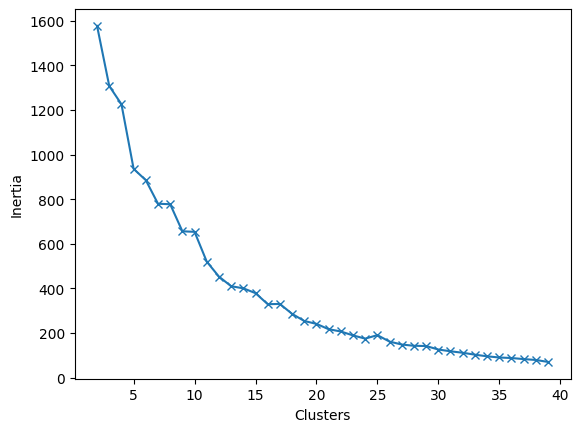

In [22]:
inertia = []
k_range = range(2, 40)
for k in k_range:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='x')
plt.xlabel('Clusters')
plt.ylabel('Inertia')
plt.show()

k-means clustering

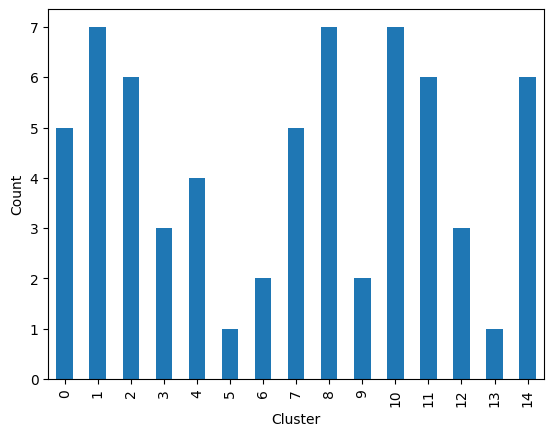

In [23]:
optimal_k = 15
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

labels['kmeans_cluster'] = kmeans_labels
labels['kmeans_cluster'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

PCA

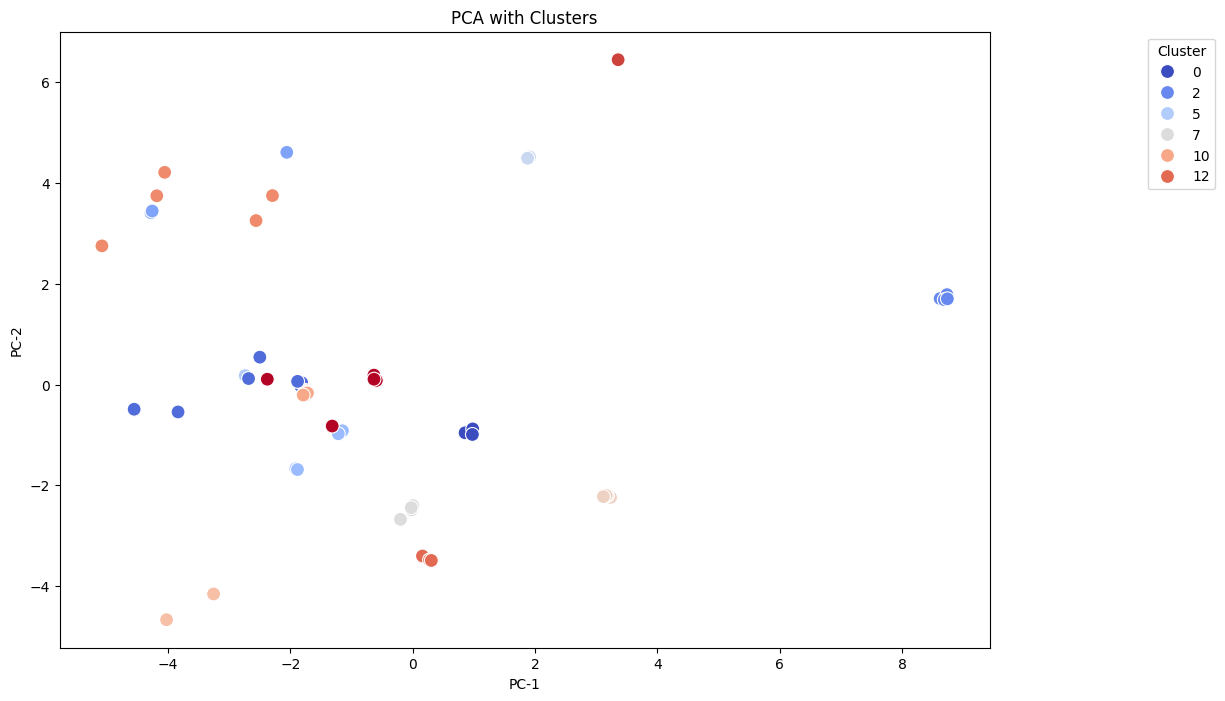


Eigenvalues: 
[12.67394914  5.87712432  2.47558836  2.23909535  1.65500253  1.42393834
  1.31933872  0.94763169  0.8148113   0.55310206]

Explained Variance Ratio: 
[0.38061281 0.17649659 0.07434468 0.06724253 0.04970157 0.04276245
 0.03962121 0.02845844 0.02446969 0.01661027]

Number of PCs for 95% variance: 16

Variance explained by top 5 PCs: 74.84%


In [29]:
pca = PCA(random_state=rs)
X_pca = pca.fit_transform(X)

eigenvalues = pca.explained_variance_
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

for i in range(5):
    labels[f'pca_component_{i+1}'] = X_pca[:, i]

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='coolwarm', s=100)
# for i, name in enumerate(labels['name']):
#     plt.text(X_pca[i, 0], X_pca[i, 1], name, fontsize=8)
plt.xlabel('PC-1')
plt.ylabel('PC-2')
plt.title('PCA with Clusters')
plt.legend(title='Cluster', loc='upper right', bbox_to_anchor=(1.25, 1))
plt.show()

print(f"\nEigenvalues: \n{eigenvalues[:10]}")
print(f"\nExplained Variance Ratio: \n{explained_variance_ratio[:10]}")
print(f"\nNumber of PCs for 95% variance: {n_components_95}")
print(f"\nVariance explained by top 5 PCs: {cumulative_variance[4]*100:.2f}%")

T-SNE

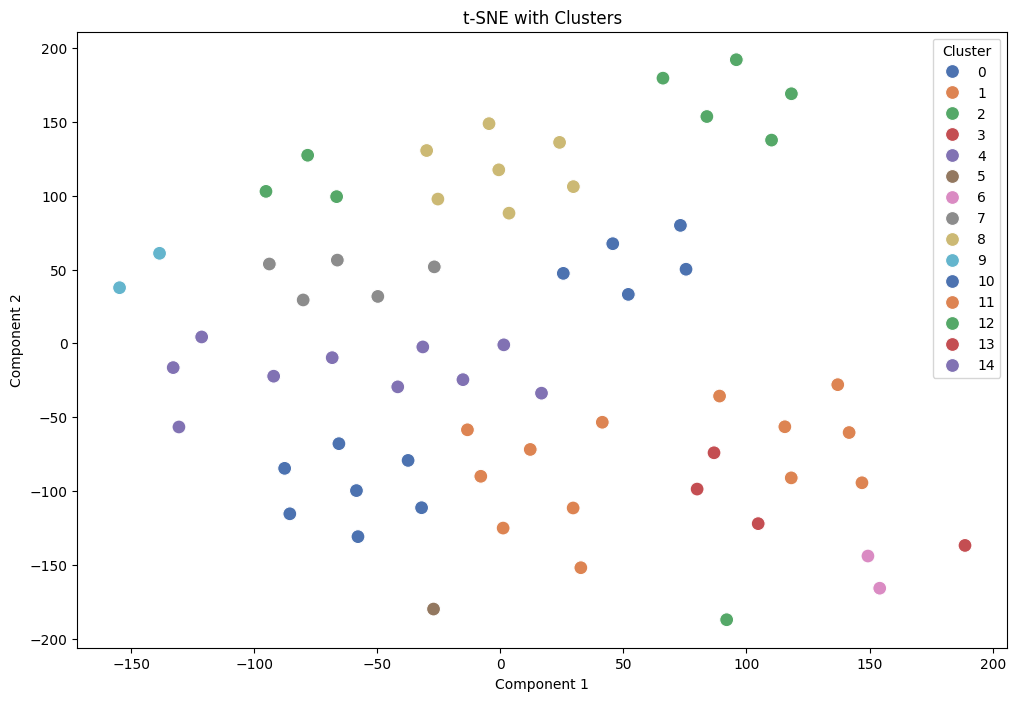

In [30]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X)

labels['tsne_x'] = X_tsne[:, 0]
labels['tsne_y'] = X_tsne[:, 1]

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=kmeans_labels, palette='deep', s=100)
# for i, name in enumerate(labels['name']):
#     plt.text(X_tsne[i, 0], X_tsne[i, 1], name, fontsize=8)
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('t-SNE with Clusters')
plt.legend(title='Cluster')
plt.show()

LDA

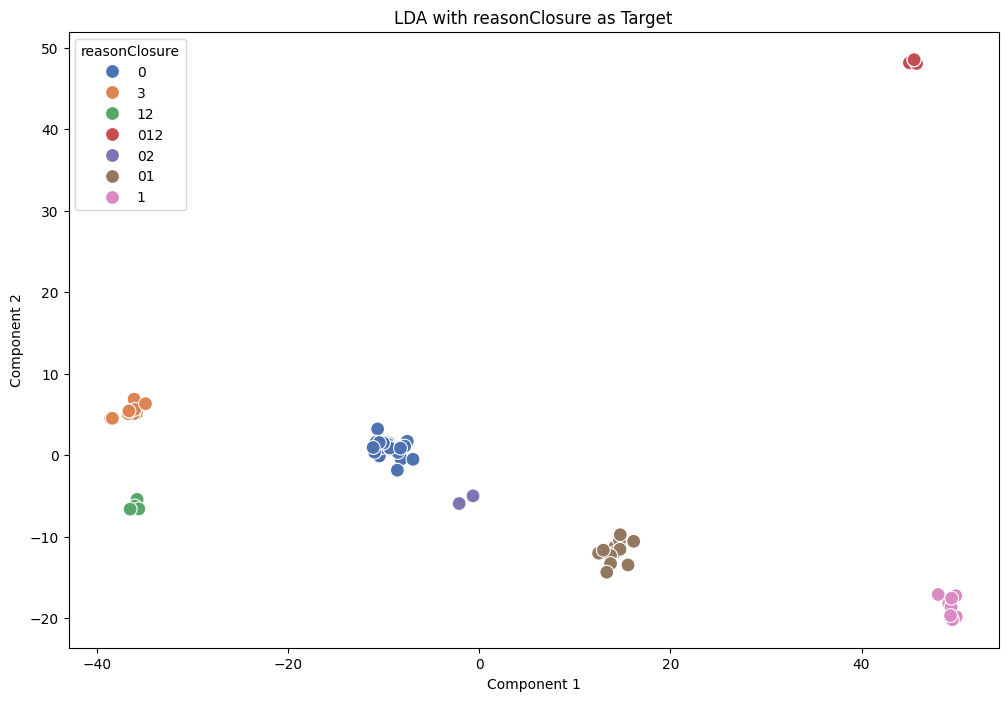


Explained Variance Ratio: 
[0.72922704 0.22003456 0.03666762 0.00738186 0.0052338  0.00145512]


In [31]:
y_reason = labels['reasonClosure']
if len(np.unique(y_reason)) > 1:
    n_components = min(len(np.unique(y_reason)) - 1, X.shape[1])
    lda_reason = LinearDiscriminantAnalysis(n_components=n_components)
    X_lda_reason = lda_reason.fit_transform(X, y_reason)
    
    for i in range(X_lda_reason.shape[1]):
        labels[f'lda_reason_component_{i+1}'] = X_lda_reason[:, i]
    
    if X_lda_reason.shape[1] >= 2:
        plt.figure(figsize=(12, 8))
        scatter = sns.scatterplot(x=X_lda_reason[:, 0], y=X_lda_reason[:, 1], hue=y_reason, palette='deep', s=100)
        # for i, name in enumerate(labels['name']):
        #     plt.text(X_lda_reason[i, 0], X_lda_reason[i, 1], name, fontsize=8)
        plt.xlabel('Component 1')
        plt.ylabel('Component 2')
        plt.title('LDA with reasonClosure as Target')
        plt.legend(title='reasonClosure')
        plt.show()
    
    print(f"\nExplained Variance Ratio: \n{lda_reason.explained_variance_ratio_}")

In [47]:
lda_reason.intercept_

array([ -2854.97110449,   3941.87113029,  11457.28878527,   -281.09315344,
        13009.58378986, -11170.79104027, -11561.17205331])

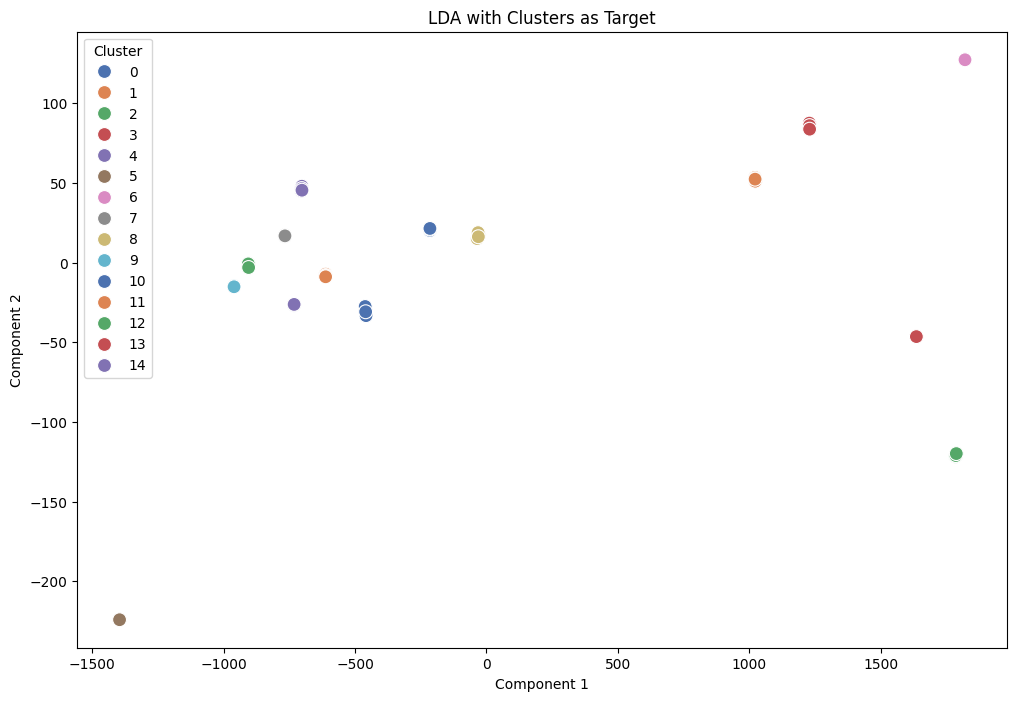


Explained Variance Ratio: 
[9.94326998e-01 4.12023743e-03 6.64827411e-04 3.44585962e-04
 2.25100819e-04 1.45748785e-04 5.70732416e-05 4.44467924e-05
 3.96318768e-05 1.51745330e-05 8.01968796e-06 4.44157220e-06
 2.57220949e-06 1.14213552e-06]


In [32]:
if len(np.unique(kmeans_labels)) > 1:
    lda_kmeans = LinearDiscriminantAnalysis(n_components=min(optimal_k-1, X.shape[1]))
    X_lda_kmeans = lda_kmeans.fit_transform(X, kmeans_labels)
    
    for i in range(X_lda_kmeans.shape[1]):
        labels[f'lda_kmeans_component_{i+1}'] = X_lda_kmeans[:, i]

    if X_lda_kmeans.shape[1] >= 2:
        plt.figure(figsize=(12, 8))
        scatter = sns.scatterplot(x=X_lda_kmeans[:, 0], y=X_lda_kmeans[:, 1], hue=kmeans_labels, palette='deep', s=100)
        # for i, name in enumerate(labels['name']):
        #     plt.text(X_lda_kmeans[i, 0], X_lda_kmeans[i, 1], name, fontsize=8)
        plt.xlabel('Component 1')
        plt.ylabel('Component 2')
        plt.title('LDA with Clusters as Target')
        plt.legend(title='Cluster')
        plt.show()
    
        print(f"\nExplained Variance Ratio: \n{lda_kmeans.explained_variance_ratio_}")

summary of clusters

In [36]:
print(f"Cluster Sizes: \n\n{labels['kmeans_cluster'].value_counts(normalize=True)}")

# print("\nTop Features per K-Means Cluster (Mean):")
# for cluster in range(optimal_k):
#     cluster_data = X_processed[labels['kmeans_cluster'] == cluster]
#     print(f"\nCluster {cluster} Top 5 Features:")
#     print(cluster_data.mean().sort_values(ascending=True).head(5))

print("\nTop Features per Cluster (by Variance):")
for cluster in range(optimal_k):
    cluster_data = X_processed[labels['kmeans_cluster'] == cluster]
    print(f"\nCluster {cluster} Top 5 Features by Variance:")
    print(cluster_data.var().sort_values(ascending=False).head(10))

Cluster Sizes: 

kmeans_cluster
8     0.107692
10    0.107692
1     0.107692
14    0.092308
2     0.092308
11    0.092308
7     0.076923
0     0.076923
4     0.061538
3     0.046154
12    0.046154
6     0.030769
9     0.030769
5     0.015385
13    0.015385
Name: proportion, dtype: float64

Top Features per Cluster (by Variance):

Cluster 0 Top 5 Features by Variance:
isMerged_TRUE                                     0.3
isMerged_FALSE                                    0.3
hasSpecialDemographic_True                        0.3
hasReligionAffiliation_True                       0.3
hasGraduate_True                                  0.3
locationTypeKind_Large                            0.3
locationType_Town                                 0.3
locationType_Rural                                0.2
carnegieProgram_Small Programs                    0.2
carnegieProgram_Mixed Baccalaureate/Associates    0.2
dtype: float64

Cluster 1 Top 5 Features by Variance:
stateTwoYearStudentShareMedian      